#### **AMEX Default Prediction: LightGBM + SHAP + LIME**

This notebook builds a competitive customer-level LightGBM baseline for the Kaggle AMEX Default Prediction competition, evaluates it with the official AMEX metric, and then uses SHAP and LIME to interpret model behavior.

Sections:
1. EDA
2. Feature preparation and engineering
3. Model definition and hyperparameter optimization
4. Result evaluation and submission
5. Interpretability with SHAP and LIME

In [12]:
# If LIME is missing in your environment, install it before running the notebook.
# On Kaggle this requires Internet to be enabled or the package to be attached as a dataset/wheel.
# !pip install -q lime

from pathlib import Path
import gc
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
import lightgbm as lgb
import optuna

import shap
from lime.lime_tabular import LimeTabularExplainer

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42

In [13]:
TRAIN_DATA = "./data/train_data.csv"
TEST_DATA = "./data/test_data.csv"
TRAIN_LABELS = "./data/train_labels.csv"
SAMPLE_SUBMISSION = "./data/sample_submission.csv"

# Keep these modest while iterating. Increase for a stronger final run.
N_FOLDS = 5
N_TRIALS = 25
EARLY_STOPPING_ROUNDS = 200
MAX_BOOST_ROUNDS = 10000

#### **Defining the Competition Metric**

The official AMEX metric averages two components: normalized weighted Gini and default capture rate at 4% of weighted observations. Negative labels receive weight 20, positive labels receive weight 1.

In [14]:
def amex_metric(y_true, y_pred):
    """Official AMEX competition metric."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    labels = np.transpose(np.array([y_true, y_pred]))
    labels = labels[labels[:, 1].argsort()[::-1]]
    weights = np.where(labels[:, 0] == 0, 20, 1)
    cut_vals = labels[np.cumsum(weights) <= int(0.04 * np.sum(weights))]
    top_four = np.sum(cut_vals[:, 0]) / np.sum(labels[:, 0])

    gini = [0, 0]
    for i in [1, 0]:
        labels = np.transpose(np.array([y_true, y_pred]))
        labels = labels[labels[:, i].argsort()[::-1]]
        weight = np.where(labels[:, 0] == 0, 20, 1)
        weight_random = np.cumsum(weight / np.sum(weight))
        total_pos = np.sum(labels[:, 0] * weight)
        cum_pos_found = np.cumsum(labels[:, 0] * weight)
        lorentz = cum_pos_found / total_pos
        gini[i] = np.sum((lorentz - weight_random) * weight)
    return 0.5 * (gini[1] / gini[0] + top_four)


def lgb_amex_metric(y_pred, dataset):
    y_true = dataset.get_label()
    return "amex", amex_metric(y_true, y_pred), True

#### **EDA**

In [15]:
labels = pd.read_csv(TRAIN_LABELS)
sample_sub = pd.read_csv(SAMPLE_SUBMISSION)
sample_train = pd.read_csv(TRAIN_DATA, nrows=200_000)

print("labels:", labels.shape)
print("sample train rows:", sample_train.shape)
print("sample submission:", sample_sub.shape)
display(labels.head())
display(sample_train.head())

labels: (458913, 2)
sample train rows: (200000, 190)
sample submission: (924621, 2)


,customer_ID,target
0,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,0
1,00000fd6641609c6ece5454664794f0340ad84dddce9a2...,0
2,00001b22f846c82c51f6e3958ccd81970162bae8b007e8...,0
3,000041bdba6ecadd89a52d11886e8eaaec9325906c9723...,0
4,00007889e4fcd2614b6cbe7f8f3d2e5c728eca32d9eb8a...,0


,customer_ID,S_2,P_2,D_39,B_1,B_2,R_1,S_3,D_41,B_3,D_42,D_43,D_44,B_4,D_45,B_5,R_2,D_46,D_47,D_48,D_49,B_6,B_7,B_8,D_50,D_51,B_9,R_3,D_52,P_3,B_10,D_53,S_5,B_11,S_6,D_54,R_4,S_7,B_12,S_8,D_55,D_56,B_13,R_5,D_58,S_9,B_14,D_59,D_60,D_61,B_15,S_11,D_62,D_63,D_64,D_65,B_16,B_17,B_18,B_19,D_66,B_20,D_68,S_12,R_6,S_13,B_21,D_69,B_22,D_70,D_71,D_72,S_15,B_23,D_73,P_4,D_74,D_75,D_76,B_24,R_7,D_77,B_25,B_26,D_78,D_79,R_8,R_9,S_16,D_80,R_10,R_11,B_27,D_81,D_82,S_17,R_12,B_28,R_13,D_83,R_14,R_15,D_84,R_16,B_29,B_30,S_18,D_86,D_87,R_17,R_18,D_88,B_31,S_19,R_19,B_32,S_20,R_20,R_21,B_33,D_89,R_22,R_23,D_91,D_92,D_93,D_94,R_24,R_25,D_96,S_22,S_23,S_24,S_25,S_26,D_102,D_103,D_104,D_105,D_106,D_107,B_36,B_37,R_26,R_27,B_38,D_108,D_109,D_110,D_111,B_39,D_112,B_40,S_27,D_113,D_114,D_115,D_116,D_117,D_118,D_119,D_120,D_121,D_122,D_123,D_124,D_125,D_126,D_127,D_128,D_129,B_41,B_42,D_130,D_131,D_132,D_133,R_28,D_134,D_135,D_136,D_137,D_138,D_139,D_140,D_141,D_142,D_143,D_144,D_145
0,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-03-09,0.938469,0.001733,0.008724,1.006838,0.009228,0.124035,0.008771,0.004709,NaN,NaN,0.000630,0.080986,0.708906,0.170600,0.006204,0.358587,0.525351,0.255736,NaN,0.063902,0.059416,0.006466,0.148698,1.335856,0.008207,0.001423,0.207334,0.736463,0.096219,NaN,0.023381,0.002768,0.008322,1.001519,0.008298,0.161345,0.148266,0.922998,0.354596,0.152025,0.118075,0.001882,0.158612,0.065728,0.018385,0.063646,0.199617,0.308233,0.016361,0.401619,0.091071,CR,O,0.007126,0.007665,NaN,0.652984,0.008520,NaN,0.004730,6.0,0.272008,0.008363,0.515222,0.002644,0.009013,0.004808,0.008342,0.119403,0.004802,0.108271,0.050882,NaN,0.007554,0.080422,0.069067,NaN,0.004327,0.007562,NaN,0.007729,0.000272,0.001576,0.004239,0.001434,NaN,0.002271,0.004061,0.007121,0.002456,0.002310,0.003532,0.506612,0.008033,1.009825,0.084683,0.003820,0.007043,0.000438,0.006452,0.000830,0.005055,NaN,0.0,0.005720,0.007084,NaN,0.000198,0.008907,NaN,1,0.002537,0.005177,0.006626,0.009705,0.007782,0.002450,1.001101,0.002665,0.007479,0.006893,1.503673,1.006133,0.003569,0.008871,0.003950,0.003647,0.004950,0.894090,0.135561,0.911191,0.974539,0.001243,0.766688,1.008691,1.004587,0.893734,NaN,0.670041,0.009968,0.004572,NaN,1.008949,2.0,NaN,0.004326,NaN,NaN,NaN,1.007336,0.210060,0.676922,0.007871,1.0,0.238250,0.0,4.0,0.232120,0.236266,0.0,0.702280,0.434345,0.003057,0.686516,0.008740,1.0,1.003319,1.007819,1.000080,0.006805,NaN,0.002052,0.005972,NaN,0.004345,0.001535,NaN,NaN,NaN,NaN,NaN,0.002427,0.003706,0.003818,NaN,0.000569,0.000610,0.002674
1,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-04-07,0.936665,0.005775,0.004923,1.000653,0.006151,0.126750,0.000798,0.002714,NaN,NaN,0.002526,0.069419,0.712795,0.113239,0.006206,0.353630,0.521311,0.223329,NaN,0.065261,0.057744,0.001614,0.149723,1.339794,0.008373,0.001984,0.202778,0.720886,0.099804,NaN,0.030599,0.002749,0.002482,1.009033,0.005136,0.140951,0.143530,0.919414,0.326757,0.156201,0.118737,0.001610,0.148459,0.093935,0.013035,0.065501,0.151387,0.265026,0.017688,0.406326,0.086805,CR,O,0.002413,0.007148,NaN,0.647093,0.002238,NaN,0.003879,6.0,0.188970,0.004030,0.509048,0.004193,0.007842,0.001283,0.006524,0.140611,0.000094,0.101018,0.040469,NaN,0.004832,0.081413,0.074166,NaN,0.004203,0.005304,NaN,0.001864,0.000979,0.009896,0.007597,0.000509,NaN,0.009810,0.000127,0.005966,0.000395,0.001327,0.007773,0.500855,0.000760,1.009461,0.081843,0.000347,0.007789,0.004311,0.002332,0.009469,0.003753,NaN,0.0,0.007584,0.006677,NaN,0.001142,0.005907,NaN,1,0.008427,0.008979,0.001854,0.009924,0.005987,0.002247,1.006779,0.002508,0.006827,0.002837,1.503577,1.005791,0.000571,0.000391,0.008351,0.008850,0.003180,0.902135,0.136333,0.919876,0.975624,0.004561,0.786007,1.000084,1.004118,0.906841,NaN,0.668647,0.003921,0.004654,NaN,1.003205,2.0,NaN,0.008707,NaN,NaN,NaN,1.007653,0.184093,0.822281,0.003444,1.0,0.247217,0.0,4.0,0.243532,0.241885,0.0,0.707017,0.430501,0.001306,0.686414,0.000755,1.0,1.008394,1.004333,1.008344,0.004407,NaN,0.001034,0.004838,NaN,0.

In [16]:
sample_train

,customer_ID,S_2,P_2,D_39,B_1,B_2,R_1,S_3,D_41,B_3,D_42,D_43,D_44,B_4,D_45,B_5,R_2,D_46,D_47,D_48,D_49,B_6,B_7,B_8,D_50,D_51,B_9,R_3,D_52,P_3,B_10,D_53,S_5,B_11,S_6,D_54,R_4,S_7,B_12,S_8,D_55,D_56,B_13,R_5,D_58,S_9,B_14,D_59,D_60,D_61,B_15,S_11,D_62,D_63,D_64,D_65,B_16,B_17,B_18,B_19,D_66,B_20,D_68,S_12,R_6,S_13,B_21,D_69,B_22,D_70,D_71,D_72,S_15,B_23,D_73,P_4,D_74,D_75,D_76,B_24,R_7,D_77,B_25,B_26,D_78,D_79,R_8,R_9,S_16,D_80,R_10,R_11,B_27,D_81,D_82,S_17,R_12,B_28,R_13,D_83,R_14,R_15,D_84,R_16,B_29,B_30,S_18,D_86,D_87,R_17,R_18,D_88,B_31,S_19,R_19,B_32,S_20,R_20,R_21,B_33,D_89,R_22,R_23,D_91,D_92,D_93,D_94,R_24,R_25,D_96,S_22,S_23,S_24,S_25,S_26,D_102,D_103,D_104,D_105,D_106,D_107,B_36,B_37,R_26,R_27,B_38,D_108,D_109,D_110,D_111,B_39,D_112,B_40,S_27,D_113,D_114,D_115,D_116,D_117,D_118,D_119,D_120,D_121,D_122,D_123,D_124,D_125,D_126,D_127,D_128,D_129,B_41,B_42,D_130,D_131,D_132,D_133,R_28,D_134,D_135,D_136,D_137,D_138,D_139,D_140,D_141,D_142,D_143,D_144,D_145
0,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-03-09,0.938469,0.001733,0.008724,1.006838,0.009228,0.124035,0.008771,0.004709,NaN,NaN,0.000630,0.080986,0.708906,0.170600,0.006204,0.358587,0.525351,0.255736,NaN,0.063902,0.059416,0.006466,0.148698,1.335856,0.008207,0.001423,0.207334,0.736463,0.096219,NaN,0.023381,0.002768,0.008322,1.001519,0.008298,0.161345,0.148266,0.922998,0.354596,0.152025,0.118075,0.001882,0.158612,0.065728,0.018385,0.063646,0.199617,0.308233,0.016361,0.401619,0.091071,CR,O,0.007126,0.007665,NaN,0.652984,0.008520,NaN,0.004730,6.0,0.272008,0.008363,0.515222,0.002644,0.009013,0.004808,0.008342,0.119403,0.004802,0.108271,0.050882,NaN,0.007554,0.080422,0.069067,NaN,0.004327,0.007562,NaN,0.007729,0.000272,0.001576,0.004239,0.001434,NaN,0.002271,0.004061,0.007121,0.002456,0.002310,0.003532,0.506612,0.008033,1.009825,0.084683,0.003820,0.007043,0.000438,0.006452,0.000830,0.005055,NaN,0.0,0.005720,0.007084,NaN,0.000198,0.008907,NaN,1,0.002537,0.005177,0.006626,0.009705,0.007782,0.002450,1.001101,0.002665,0.007479,0.006893,1.503673,1.006133,0.003569,0.008871,0.003950,0.003647,0.004950,0.894090,0.135561,0.911191,0.974539,0.001243,0.766688,1.008691,1.004587,0.893734,NaN,0.670041,0.009968,0.004572,NaN,1.008949,2.0,NaN,0.004326,NaN,NaN,NaN,1.007336,0.210060,0.676922,0.007871,1.0,0.238250,0.0,4.0,0.232120,0.236266,0.0,0.702280,0.434345,0.003057,0.686516,0.008740,1.0,1.003319,1.007819,1.000080,0.006805,NaN,0.002052,0.005972,NaN,0.004345,0.001535,NaN,NaN,NaN,NaN,NaN,0.002427,0.003706,0.003818,NaN,0.000569,0.000610,0.002674
1,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-04-07,0.936665,0.005775,0.004923,1.000653,0.006151,0.126750,0.000798,0.002714,NaN,NaN,0.002526,0.069419,0.712795,0.113239,0.006206,0.353630,0.521311,0.223329,NaN,0.065261,0.057744,0.001614,0.149723,1.339794,0.008373,0.001984,0.202778,0.720886,0.099804,NaN,0.030599,0.002749,0.002482,1.009033,0.005136,0.140951,0.143530,0.919414,0.326757,0.156201,0.118737,0.001610,0.148459,0.093935,0.013035,0.065501,0.151387,0.265026,0.017688,0.406326,0.086805,CR,O,0.002413,0.007148,NaN,0.647093,0.002238,NaN,0.003879,6.0,0.188970,0.004030,0.509048,0.004193,0.007842,0.001283,0.006524,0.140611,0.000094,0.101018,0.040469,NaN,0.004832,0.081413,0.074166,NaN,0.004203,0.005304,NaN,0.001864,0.000979,0.009896,0.007597,0.000509,NaN,0.009810,0.000127,0.005966,0.000395,0.001327,0.007773,0.500855,0.000760,1.009461,0.081843,0.000347,0.007789,0.004311,0.002332,0.009469,0.003753,NaN,0.0,0.007584,0.006677,NaN,0.001142,0.005907,NaN,1,0.008427,0.008979,0.001854,0.009924,0.005987,0.002247,1.006779,0.002508,0.006827,0.002837,1.503577,1.005791,0.000571,0.000391,0.008351,0.008850,0.003180,0.902135,0.136333,0.919876,0.975624,0.004561,0.786007,1.000084,1.004118,0.906841,NaN,0.668647,0.003921,0.004654,NaN,1.003205,2.0,NaN,0.008707,NaN,NaN,NaN,1.007653,0.184093,0.822281,0.003444,1.0,0.247217,0.0,4.0,0.243532,0.241885,0.0,0.707017,0.430501,0.001306,0.686414,0.000755,1.0,1.008394,1.004333,1.008344,0.004407,NaN,0.001034,0.004838,NaN,0.

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_ID,200000,16576,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
S_2,200000,396,2018-02-17,933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
P_2,198458.0,NaN,NaN,NaN,0.653527,0.246135,-0.383019,0.476334,0.691541,0.863455,1.009998
D_39,200000.0,NaN,NaN,NaN,0.153413,0.272381,0.0,0.004541,0.009066,0.236017,5.33136
B_1,200000.0,NaN,NaN,NaN,0.125356,0.213396,-0.899396,0.008858,0.031935,0.129569,1.324053
B_2,199928.0,NaN,NaN,NaN,0.616971,0.402275,0.000003,0.10055,0.814164,1.00224,1.01
R_1,200000.0,NaN,NaN,NaN,0.081215,0.230995,0.0,0.0029,0.005793,0.008685,2.507711
S_3,162335.0,NaN,NaN,NaN,0.227386,0.197101,-0.254707,0.127432,0.164248,0.260202,2.918675
D_41,199928.0,NaN,NaN,NaN,0.062218,0.208162,0.0,0.002898,0.005769,0.008653,6.798167
B_3,199928.0,NaN,NaN,NaN,0.134392,0.234849,0.0,0.005291,0.009873,0.163591,1.625262


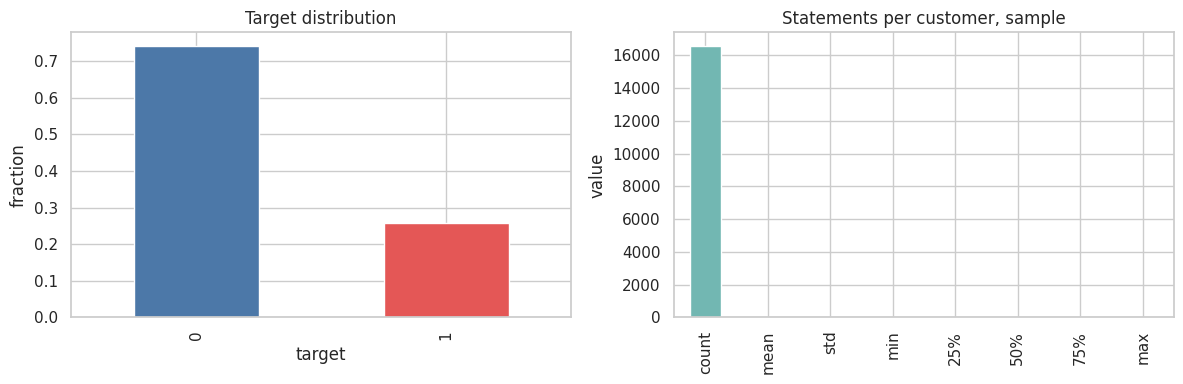

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
labels["target"].value_counts(normalize=True).sort_index().plot(kind="bar", ax=axes[0], color=["#4C78A8", "#E45756"])
axes[0].set_title("Target distribution")
axes[0].set_xlabel("target")
axes[0].set_ylabel("fraction")

sample_train.groupby("customer_ID").size().describe().plot(kind="bar", ax=axes[1], color="#72B7B2")
axes[1].set_title("Statements per customer, sample")
axes[1].set_ylabel("value")
plt.tight_layout()

display(sample_train.describe(include="all").T.head(30))

#### **Some Feature Preparation and Engineering**

The raw data is monthly statement history. LightGBM usually performs well after aggregating each customer's history into fixed-length features. This notebook uses:

- numeric aggregations: last, mean, standard deviation, min, max
- categorical aggregations: last and number of unique values
- statement history features: number of statements and observed date span
- trend features: last minus first for important high-signal numeric columns

In [18]:
CAT_COLS = [
    "B_30", "B_38", "D_114", "D_116", "D_117", "D_120", "D_126",
    "D_63", "D_64", "D_66", "D_68"
]

TREND_COLS = [
    "P_2", "D_39", "B_1", "B_2", "R_1", "S_3", "D_41", "B_3", "D_42", "D_44",
    "D_45", "D_48", "B_9", "D_55", "D_61", "S_23", "D_75", "D_102", "B_37", "R_27"
]


def dtype_map(path):
    columns = pd.read_csv(path, nrows=0).columns.tolist()
    dtypes = {}
    for col in columns:
        if col in ["customer_ID", "S_2"]:
            continue
        if col in CAT_COLS:
            dtypes[col] = "category"
        else:
            dtypes[col] = "float32"
    return dtypes


def read_statement_data(path):
    df = pd.read_csv(path, dtype=dtype_map(path), parse_dates=["S_2"])
    df = df.sort_values(["customer_ID", "S_2"]).reset_index(drop=True)
    return df


def flatten_columns(df):
    df.columns = ["_".join([str(x) for x in col if x != ""]) for col in df.columns.to_flat_index()]
    return df


def make_customer_features(df):
    existing_cat = [c for c in CAT_COLS if c in df.columns]
    numeric_cols = [c for c in df.columns if c not in ["customer_ID", "S_2"] + existing_cat]
    existing_trend = [c for c in TREND_COLS if c in numeric_cols]
    group = df.groupby("customer_ID", sort=False)

    num_features = group[numeric_cols].agg(["last", "mean", "std", "min", "max"])
    num_features = flatten_columns(num_features)

    if existing_cat:
        cat_features = group[existing_cat].agg(["last", "nunique"])
        cat_features = flatten_columns(cat_features)
    else:
        cat_features = pd.DataFrame(index=num_features.index)

    date_features = group["S_2"].agg(["min", "max", "count"])
    date_features["history_days"] = (date_features["max"] - date_features["min"]).dt.days.astype("int16")
    date_features = date_features.drop(columns=["min", "max"])
    date_features = date_features.rename(columns={"count": "statement_count"})

    first_values = group[existing_trend].first()
    last_values = group[existing_trend].last()
    trend_features = last_values.subtract(first_values)
    trend_features.columns = [f"{c}_last_minus_first" for c in trend_features.columns]

    features = pd.concat([num_features, cat_features, date_features, trend_features], axis=1)
    features = features.reset_index()
    return features

In [19]:
train_raw = read_statement_data(TRAIN_DATA)
test_raw = read_statement_data(TEST_DATA)

train_features = make_customer_features(train_raw)
test_features = make_customer_features(test_raw)

del train_raw, test_raw
gc.collect()

train = train_features.merge(labels, on="customer_ID", how="left")
test = test_features.copy()

del train_features, test_features
gc.collect()

print(train.shape, test.shape)
display(train.head())

(458913, 931) (924621, 930)


,customer_ID,P_2_last,P_2_mean,P_2_std,P_2_min,P_2_max,D_39_last,D_39_mean,D_39_std,D_39_min,D_39_max,B_1_last,B_1_mean,B_1_std,B_1_min,B_1_max,B_2_last,B_2_mean,B_2_std,B_2_min,B_2_max,R_1_last,R_1_mean,R_1_std,R_1_min,R_1_max,S_3_last,S_3_mean,S_3_std,S_3_min,S_3_max,D_41_last,D_41_mean,D_41_std,D_41_min,D_41_max,B_3_last,B_3_mean,B_3_std,B_3_min,B_3_max,D_42_last,D_42_mean,D_42_std,D_42_min,D_42_max,D_43_last,D_43_mean,D_43_std,D_43_min,D_43_max,D_44_last,D_44_mean,D_44_std,D_44_min,D_44_max,B_4_last,B_4_mean,B_4_std,B_4_min,B_4_max,D_45_last,D_45_mean,D_45_std,D_45_min,D_45_max,B_5_last,B_5_mean,B_5_std,B_5_min,B_5_max,R_2_last,R_2_mean,R_2_std,R_2_min,R_2_max,D_46_last,D_46_mean,D_46_std,D_46_min,D_46_max,D_47_last,D_47_mean,D_47_std,D_47_min,D_47_max,D_48_last,D_48_mean,D_48_std,D_48_min,D_48_max,D_49_last,D_49_mean,D_49_std,D_49_min,D_49_max,B_6_last,B_6_mean,B_6_std,B_6_min,...,D_135_last,D_135_mean,D_135_std,D_135_min,D_135_max,D_136_last,D_136_mean,D_136_std,D_136_min,D_136_max,D_137_last,D_137_mean,D_137_std,D_137_min,D_137_max,D_138_last,D_138_mean,D_138_std,D_138_min,D_138_max,D_139_last,D_139_mean,D_139_std,D_139_min,D_139_max,D_140_last,D_140_mean,D_140_std,D_140_min,D_140_max,D_141_last,D_141_mean,D_141_std,D_141_min,D_141_max,D_142_last,D_142_mean,D_142_std,D_142_min,D_142_max,D_143_last,D_143_mean,D_143_std,D_143_min,D_143_max,D_144_last,D_144_mean,D_144_std,D_144_min,D_144_max,D_145_last,D_145_mean,D_145_std,D_145_min,D_145_max,B_30_last,B_30_nunique,B_38_last,B_38_nunique,D_114_last,D_114_nunique,D_116_last,D_116_nunique,D_117_last,D_117_nunique,D_120_last,D_120_nunique,D_126_last,D_126_nunique,D_63_last,D_63_nunique,D_64_last,D_64_nunique,D_66_last,D_66_nunique,D_68_last,D_68_nunique,statement_count,history_days,P_2_last_minus_first,D_39_last_minus_first,B_1_last_minus_first,B_2_last_minus_first,R_1_last_minus_first,S_3_last_minus_first,D_41_last_minus_first,B_3_last_minus_first,D_42_last_minus_first,D_44_last_minus_first,D_45_last_minus_first,D_48_last_minus_first,B_9_last_minus_first,D_55_last_minus_first,D_61_last_minus_first,S_23_last_minus_first,D_75_last_minus_first,D_102_last_minus_first,B_37_last_minus_first,R_27_last_minus_first,target
0,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,0.934745,0.933824,0.024194,0.868580,0.960384,0.009119,0.010704,0.024444,0.001082,0.091505,0.009382,0.012007,0.006547,0.001930,0.021655,1.007647,1.005086,0.003222,1.000242,1.009672,0.006104,0.004509,0.003081,0.000263,0.009228,0.135021,0.113215,0.011670,0.098882,0.135021,0.001604,0.005021,0.003331,0.000685,0.009857,0.007174,0.006456,0.002942,0.000783,0.009866,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.003258,0.004673,0.002822,0.000630,0.009397,0.070793,0.040309,0.031726,0.000836,0.080986,0.740102,0.725369,0.009515,0.708906,0.740102,0.231717,0.146650,0.047205,0.060492,0.231717,0.008309,0.005754,0.002929,0.001436,0.009918,0.420521,0.378074,0.085674,0.231009,0.519619,0.539715,0.532874,0.006578,0.521311,0.542119,0.192376,0.240978,0.076875,0.135586,0.403448,NaN,NaN,NaN,NaN,NaN,0.149564,0.113510,0.047360,0.063902,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.007186,0.003664,0.002615,0.000427,0.009742,0.004234,0.005343,0.002356,0.001976,0.009607,0.005086,0.005178,0.002609,0.000427,0.009387,NaN,NaN,NaN,NaN,NaN,0.005810,0.005066,0.003564,0.000569,0.009576,0.002970,0.005283,0.002598,0.000610,0.009616,0.008533,0.005814,0.003294,0.000995,0.009827,0.0,1,2.0,1,1.0,1,0.0,1,4.0,1,0.0,1,1.0,1,CR,1,O,1,NaN,0,6.0,1,13,369,-0.003724,0.007385,0.000658,0.000809,-0.003124,0.010986,-0.007167,0.002465,NaN,0.002628,0.031196,-0.063360,0.001328,-0.167311,-0.080596,-0.003760,-0.067715,0.176652,0.004105,-0.002819,0
1,00000fd6641609c6ece5454664794f0340ad84dddce9a2...,0.880519,0.899820,0.022119,0.861109,0.929122,0.178126,0.215205,0.199150,0.002224,0.567403,0.034684,0.025654,0.027756,0.006711,0.109644,1.004028,0.991083,0.051531,0.819772,1.008534,0.006911,0.006246,0.002129,0.001023,0.008996,0.165509,0.120578,0.0

In [20]:
target = train["target"].astype("int8")
train_ids = train["customer_ID"]
test_ids = test["customer_ID"]

X = train.drop(columns=["customer_ID", "target"])
X_test = test.drop(columns=["customer_ID"])

cat_features = [c for c in X.columns if c.endswith("_last") and c.split("_last")[0] in CAT_COLS]
cat_features = [c for c in cat_features if c in X.columns]


def encode_categoricals(train_df, test_df, columns):
    for col in columns:
        combined = pd.concat([train_df[col], test_df[col]], axis=0).astype("string").fillna("__MISSING__")
        codes, _ = pd.factorize(combined, sort=True)
        train_df[col] = codes[: len(train_df)].astype("int16")
        test_df[col] = codes[len(train_df) :].astype("int16")
        train_df[col] = train_df[col].astype("category")
        test_df[col] = test_df[col].astype("category")
    return train_df, test_df


X, X_test = encode_categoricals(X, X_test, cat_features)

print("Training matrix:", X.shape)
print("Test matrix:", X_test.shape)
print("Categorical features:", len(cat_features))

Training matrix: (458913, 929)
Test matrix: (924621, 929)
Categorical features: 11


#### **Model Hyperparameter Optimization**

In [21]:
base_params = {
    "objective": "binary",
    "boosting_type": "gbdt",
    "metric": "None",
    "random_state": RANDOM_STATE,
    "verbosity": -1,
    "n_jobs": -1,
}


def suggest_lgb_params(trial):
    return {
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.08, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 32, 256),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "min_child_samples": trial.suggest_int("min_child_samples", 50, 500),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "subsample_freq": trial.suggest_int("subsample_freq", 1, 7),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 20.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 50.0, log=True),
        "min_split_gain": trial.suggest_float("min_split_gain", 0.0, 1.0),
    }


def objective(trial):
    params = {**base_params, **suggest_lgb_params(trial)}
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
    fold_scores = []

    for fold, (trn_idx, val_idx) in enumerate(cv.split(X, target), start=1):
        X_trn, X_val = X.iloc[trn_idx], X.iloc[val_idx]
        y_trn, y_val = target.iloc[trn_idx], target.iloc[val_idx]

        train_set = lgb.Dataset(X_trn, label=y_trn, categorical_feature=cat_features, free_raw_data=False)
        valid_set = lgb.Dataset(X_val, label=y_val, categorical_feature=cat_features, free_raw_data=False)

        model = lgb.train(
            params,
            train_set,
            num_boost_round=MAX_BOOST_ROUNDS,
            valid_sets=[valid_set],
            feval=lgb_amex_metric,
            callbacks=[lgb.early_stopping(EARLY_STOPPING_ROUNDS, verbose=False)],
        )

        preds = model.predict(X_val, num_iteration=model.best_iteration)
        fold_scores.append(amex_metric(y_val, preds))
        trial.report(np.mean(fold_scores), step=fold)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return float(np.mean(fold_scores))

In [22]:
study = optuna.create_study(direction="maximize", study_name="amex_lgbm")
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print("Best AMEX CV score:", study.best_value)
print("Best params:")
display(study.best_params)

best_params = {**base_params, **study.best_params}

[I 2026-04-26 14:52:00,656] A new study created in memory with name: amex_lgbm
Best trial: 0. Best value: 0.789923:   4%|▍         | 1/25 [04:49<1:55:40, 289.18s/it]

[I 2026-04-26 14:56:49,840] Trial 0 finished with value: 0.7899230562523273 and parameters: {'learning_rate': 0.05204561684978901, 'num_leaves': 151, 'max_depth': 4, 'min_child_samples': 52, 'subsample': 0.8696118673370199, 'subsample_freq': 3, 'colsample_bytree': 0.8110166363126264, 'reg_alpha': 0.00674636671699161, 'reg_lambda': 0.027169411515217307, 'min_split_gain': 0.3937843939547473}. Best is trial 0 with value: 0.7899230562523273.


Best trial: 0. Best value: 0.789923:   8%|▊         | 2/25 [11:54<2:21:29, 369.12s/it]

[I 2026-04-26 15:03:54,918] Trial 1 finished with value: 0.7893320846937216 and parameters: {'learning_rate': 0.0464831992986355, 'num_leaves': 131, 'max_depth': 10, 'min_child_samples': 194, 'subsample': 0.6118849921813072, 'subsample_freq': 2, 'colsample_bytree': 0.851274103613237, 'reg_alpha': 2.7401945136027135, 'reg_lambda': 0.024929360904636374, 'min_split_gain': 0.3165436872271601}. Best is trial 0 with value: 0.7899230562523273.


Best trial: 2. Best value: 0.791123:  12%|█▏        | 3/25 [19:42<2:31:59, 414.53s/it]

...

Best trial: 23. Best value: 0.792514:  96%|█████████▌| 24/25 [3:37:31<14:33, 873.41s/it]

[I 2026-04-26 18:29:31,866] Trial 23 finished with value: 0.7925139403018168 and parameters: {'learning_rate': 0.013253943894962861, 'num_leaves': 97, 'max_depth': 10, 'min_child_samples': 407, 'subsample': 0.8045440140138388, 'subsample_freq': 3, 'colsample_bytree': 0.6042552692007629, 'reg_alpha': 9.925325385431325, 'reg_lambda': 0.9869742768977846, 'min_split_gain': 0.25013582108121024}. Best is trial 23 with value: 0.7925139403018168.


Best trial: 23. Best value: 0.792514: 100%|██████████| 25/25 [3:42:00<00:00, 532.83s/it]

[I 2026-04-26 18:34:01,291] Trial 24 pruned. 
Best AMEX CV score: 0.7925139403018168
Best params:


{'learning_rate': 0.013253943894962861,
 'num_leaves': 97,
 'max_depth': 10,
 'min_child_samples': 407,
 'subsample': 0.8045440140138388,
 'subsample_freq': 3,
 'colsample_bytree': 0.6042552692007629,
 'reg_alpha': 9.925325385431325,
 'reg_lambda': 0.9869742768977846,
 'min_split_gain': 0.25013582108121024}

#### **Cross-Validated Training and Result Evaluation**

In [23]:
cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
oof = np.zeros(len(X), dtype=np.float32)
test_preds = np.zeros(len(X_test), dtype=np.float32)
models = []
fold_scores = []

for fold, (trn_idx, val_idx) in enumerate(cv.split(X, target), start=1):
    print(f"Fold {fold}/{N_FOLDS}")
    X_trn, X_val = X.iloc[trn_idx], X.iloc[val_idx]
    y_trn, y_val = target.iloc[trn_idx], target.iloc[val_idx]

    train_set = lgb.Dataset(X_trn, label=y_trn, categorical_feature=cat_features, free_raw_data=False)
    valid_set = lgb.Dataset(X_val, label=y_val, categorical_feature=cat_features, free_raw_data=False)

    model = lgb.train(
        best_params,
        train_set,
        num_boost_round=MAX_BOOST_ROUNDS,
        valid_sets=[train_set, valid_set],
        valid_names=["train", "valid"],
        feval=lgb_amex_metric,
        callbacks=[
            lgb.early_stopping(EARLY_STOPPING_ROUNDS, verbose=True),
            lgb.log_evaluation(200),
        ],
    )

    val_pred = model.predict(X_val, num_iteration=model.best_iteration)
    oof[val_idx] = val_pred
    test_preds += model.predict(X_test, num_iteration=model.best_iteration) / N_FOLDS
    score = amex_metric(y_val, val_pred)
    fold_scores.append(score)
    models.append(model)
    print(f"Fold {fold} AMEX metric: {score:.6f}")

print(f"OOF AMEX metric: {amex_metric(target, oof):.6f}")
print(f"Mean fold AMEX metric: {np.mean(fold_scores):.6f} +/- {np.std(fold_scores):.6f}")
print(f"OOF ROC AUC: {roc_auc_score(target, oof):.6f}")

Fold 1/5
Training until validation scores don't improve for 200 rounds
[200]	train's amex: 0.786357	valid's amex: 0.775247
[400]	train's amex: 0.807473	valid's amex: 0.786651
[600]	train's amex: 0.822942	valid's amex: 0.792568
[800]	train's amex: 0.836178	valid's amex: 0.79534
[1000]	train's amex: 0.848896	valid's amex: 0.796191
[1200]	train's amex: 0.861113	valid's amex: 0.797092
[1400]	train's amex: 0.872517	valid's amex: 0.798432
[1600]	train's amex: 0.883378	valid's amex: 0.798597
[1800]	train's amex: 0.894111	valid's amex: 0.798886
[2000]	train's amex: 0.904077	valid's amex: 0.798961
Early stopping, best iteration is:
[1842]	train's amex: 0.89629	valid's amex: 0.799324
Fold 1 AMEX metric: 0.799324
Fold 2/5
Training until validation scores don't improve for 200 rounds
[200]	train's amex: 0.787937	valid's amex: 0.767952
[400]	train's amex: 0.809915	valid's amex: 0.779316
[600]	train's amex: 0.824975	valid's amex: 0.784967
[800]	train's amex: 0.837953	valid's amex: 0.786759
[1000]	tr

Threshold used for diagnostic classification report: 0.5295803546905518
              precision    recall  f1-score   support

           0       0.93      0.94      0.94    340085
           1       0.83      0.80      0.81    118828

    accuracy                           0.90    458913
   macro avg       0.88      0.87      0.87    458913
weighted avg       0.90      0.90      0.90    458913



,pred_0,pred_1
actual_0,320031,20054
actual_1,24153,94675


,feature,gain,split
0,P_2_last,3.368185e+06,1018.4
1,P_2_mean,9.770318e+05,486.4
3,P_2_min,5.978016e+05,409.2
10,B_1_last,4.175780e+05,536.4
120,B_9_last,1.526227e+05,410.4
20,R_1_last,1.515237e+05,519.6
15,B_2_last,1.415533e+05,447.4
85,D_48_last,1.398721e+05,424.8
155,B_11_last,1.316876e+05,545.4
675,B_37_last,8.892400e+04,301.4


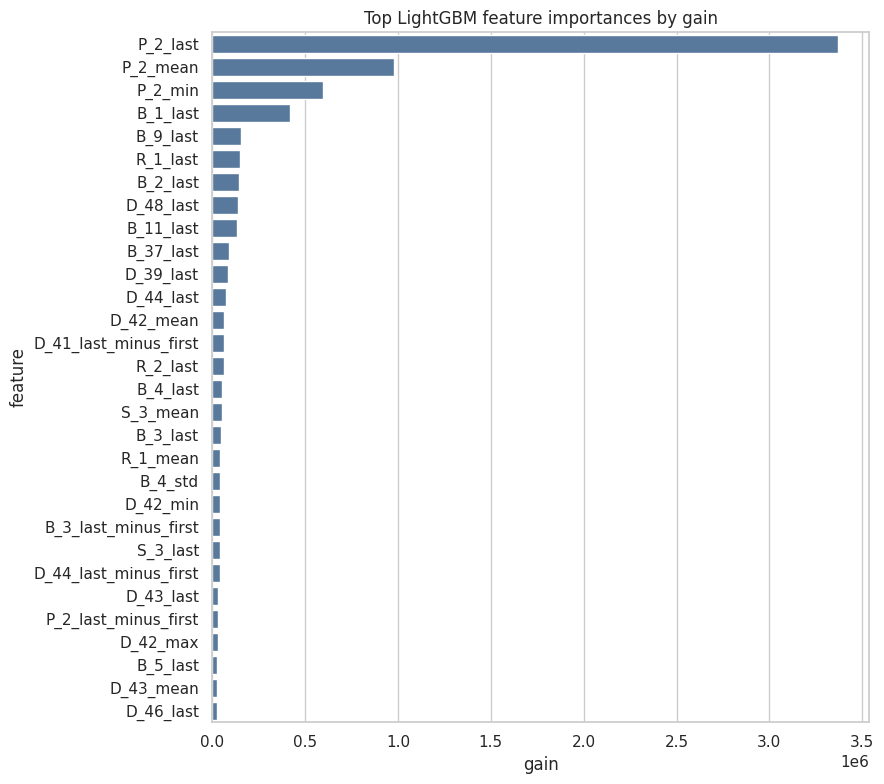

In [24]:
threshold = pd.Series(oof).quantile(0.75)
hard_preds = (oof >= threshold).astype(int)

print("Threshold used for diagnostic classification report:", threshold)
print(classification_report(target, hard_preds))
display(pd.DataFrame(confusion_matrix(target, hard_preds), index=["actual_0", "actual_1"], columns=["pred_0", "pred_1"]))

importance = pd.DataFrame({
    "feature": X.columns,
    "gain": np.mean([m.feature_importance(importance_type="gain") for m in models], axis=0),
    "split": np.mean([m.feature_importance(importance_type="split") for m in models], axis=0),
}).sort_values("gain", ascending=False)

display(importance.head(30))
plt.figure(figsize=(9, 8))
sns.barplot(data=importance.head(30), x="gain", y="feature", color="#4C78A8")
plt.title("Top LightGBM feature importances by gain")
plt.tight_layout()

#### **Creating a Submission**

In [25]:
submission = pd.DataFrame({"customer_ID": test_ids, "prediction": test_preds})
submission.to_csv("submission_lgbm.csv", index=False)
display(submission.head())
print(submission.shape)

,customer_ID,prediction
0,00000469ba478561f23a92a868bd366de6f6527a684c9a...,0.039456
1,00001bf2e77ff879fab36aa4fac689b9ba411dae63ae39...,0.000980
2,0000210045da4f81e5f122c6bde5c2a617d03eef67f82c...,0.037965
3,00003b41e58ede33b8daf61ab56d9952f17c9ad1c3976c...,0.250118
4,00004b22eaeeeb0ec976890c1d9bfc14fd9427e98c4ee9...,0.879414


(924621, 2)


### **Interpretability**

#### **SHAP**

SHAP values explain how features move predictions away from the expected prediction. For speed, use a sample of validation/training rows rather than the full dataset.

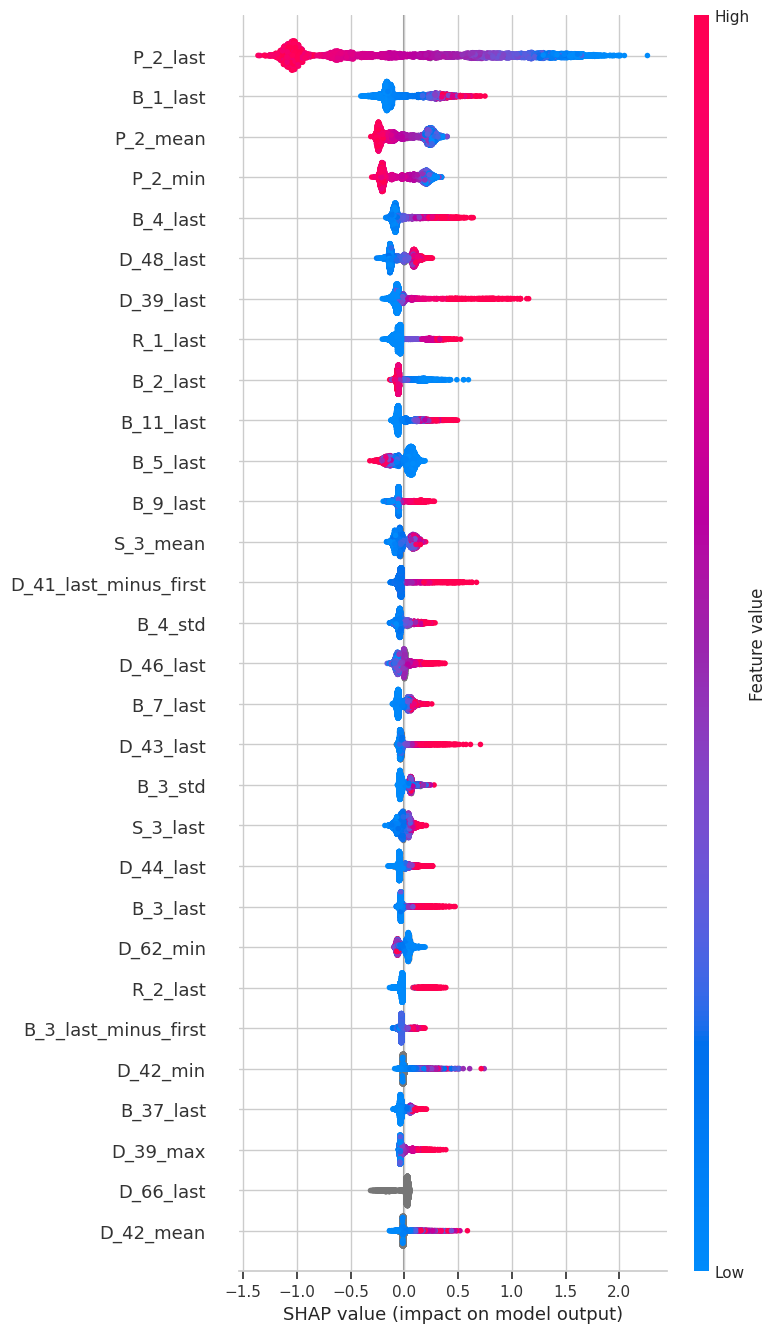

In [26]:
shap_model = models[0]
shap_sample = X.sample(n=min(5000, len(X)), random_state=RANDOM_STATE)

explainer = shap.TreeExplainer(shap_model)
shap_values = explainer.shap_values(shap_sample)
if isinstance(shap_values, list):
    shap_values_for_default = shap_values[1]
else:
    shap_values_for_default = shap_values

shap.summary_plot(shap_values_for_default, shap_sample, max_display=30)

,feature,mean_abs_shap
0,P_2_last,0.848799
10,B_1_last,0.205429
1,P_2_mean,0.191822
3,P_2_min,0.172224
55,B_4_last,0.111453
85,D_48_last,0.100095
5,D_39_last,0.098989
20,R_1_last,0.096006
15,B_2_last,0.094268
155,B_11_last,0.088493


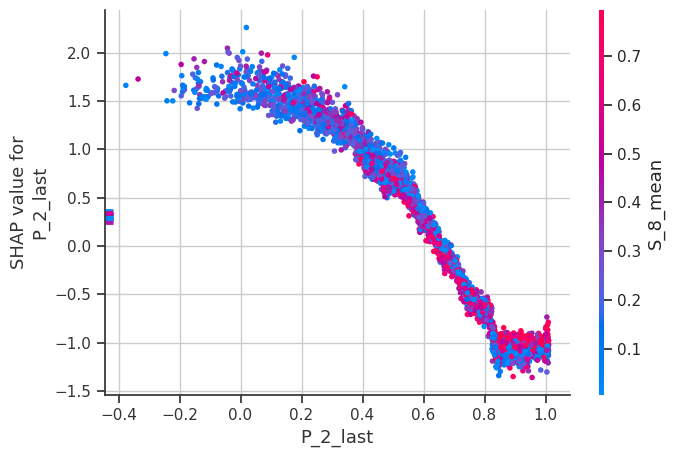

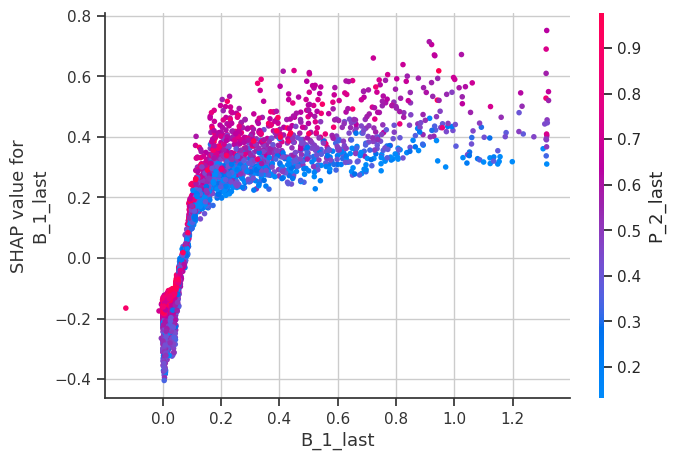

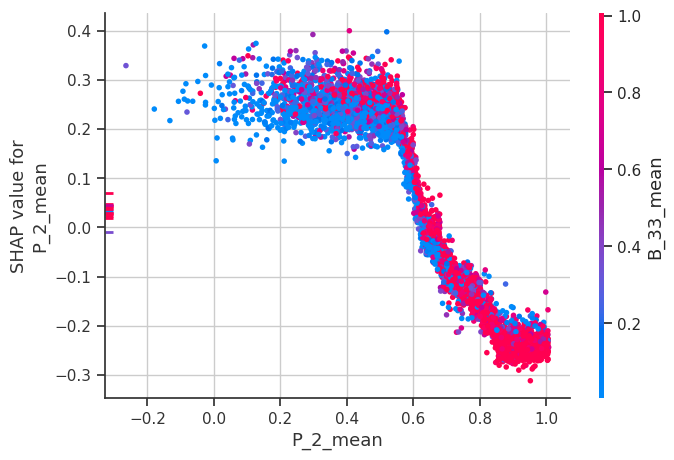

In [27]:
top_shap_features = pd.DataFrame({
    "feature": shap_sample.columns,
    "mean_abs_shap": np.abs(shap_values_for_default).mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False)

display(top_shap_features.head(30))

for feature in top_shap_features.head(3)["feature"]:
    shap.dependence_plot(feature, shap_values_for_default, shap_sample, interaction_index="auto")

#### **Interpretability: LIME**

LIME explains one prediction at a time by fitting a local surrogate model around a selected row. Use it to inspect specific customers such as high-risk, low-risk, and borderline predictions.

In [28]:
lime_model = models[0]
lime_train_raw = X.sample(n=min(10_000, len(X)), random_state=RANDOM_STATE)
numeric_medians = X.drop(columns=cat_features, errors="ignore").median(numeric_only=True)

lime_train = lime_train_raw.copy()
for col, value in numeric_medians.items():
    lime_train[col] = lime_train[col].fillna(value)

categorical_feature_idx = [lime_train.columns.get_loc(c) for c in cat_features if c in lime_train.columns]


def lime_predict_fn(values):
    values_df = pd.DataFrame(values, columns=X.columns)
    for col, value in numeric_medians.items():
        values_df[col] = values_df[col].fillna(value)
    for col in cat_features:
        if col in values_df.columns:
            values_df[col] = values_df[col].round().astype("int16").astype("category")
    proba_default = lime_model.predict(values_df, num_iteration=lime_model.best_iteration)
    return np.column_stack([1 - proba_default, proba_default])


lime_explainer = LimeTabularExplainer(
    training_data=lime_train.to_numpy(dtype=np.float32),
    feature_names=X.columns.tolist(),
    class_names=["non_default", "default"],
    categorical_features=categorical_feature_idx,
    discretize_continuous=True,
    random_state=RANDOM_STATE,
)

high_risk {'customer_ID': 'c7e69ecb9c8ea87473a7b45eac9cab1c9d4e26b52f969f9d38eb76cbd0f4d584', 'target': 1, 'oof_prediction': 0.9994331002235413}


,feature_condition,local_weight
0,P_2_last <= 0.45,0.203123
1,D_110_min <= 0.87,-0.085718
2,B_1_last > 0.15,0.066840
3,D_39_last > 0.24,0.063876
4,B_4_last > 0.26,0.045912
5,D_111_mean <= 1.00,-0.044198
6,D_88_mean <= 0.10,-0.042964
7,B_2_last <= 0.07,0.039326
8,R_1_last > 0.01,0.036809
9,D_111_last <= 1.00,-0.036171


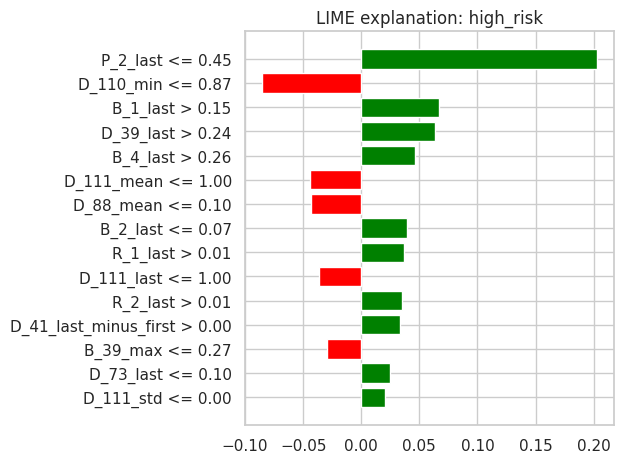

low_risk {'customer_ID': 'c0934246d1d0ef62975d7df1f1483cb307028bd7cd2c6b08b6af93f4b73a90c2', 'target': 0, 'oof_prediction': 0.00010525278776185587}


,feature_condition,local_weight
0,P_2_last > 0.86,-0.134616
1,D_88_mean <= 0.10,-0.061980
2,0.01 < B_1_last <= 0.03,-0.038863
3,R_2_last > 0.01,0.036740
4,D_111_mean <= 1.00,-0.030758
5,D_88_max <= 0.14,-0.029648
6,D_110_mean <= 0.88,-0.029131
7,D_88_min <= 0.06,-0.026632
8,P_2_mean > 0.86,-0.025183
9,D_110_min <= 0.87,0.024467


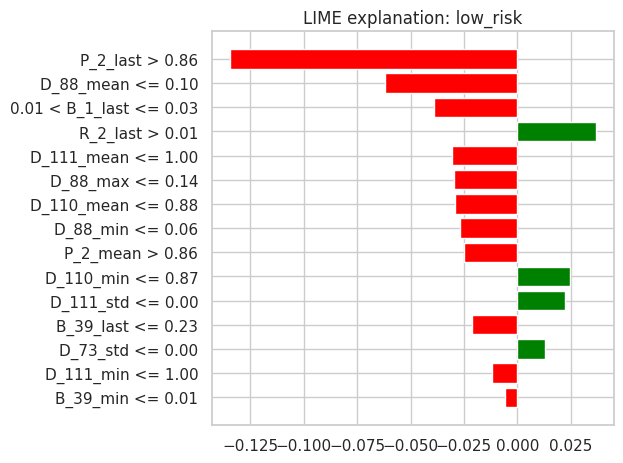

borderline {'customer_ID': 'ce7d69dac45d792b6f888b8b48a640c99186c42730b94e9aae24960a384082d7', 'target': 0, 'oof_prediction': 0.024689430370926857}


,feature_condition,local_weight
0,0.68 < P_2_last <= 0.86,-0.088185
1,D_88_max <= 0.14,-0.068737
2,D_110_max <= 0.91,-0.052019
3,B_42_std <= 0.00,0.051363
4,D_108_std <= 0.00,-0.036888
5,D_43_last > 0.14,0.034242
6,B_39_std <= 0.09,-0.034028
7,D_49_last <= 0.11,-0.030426
8,D_42_min <= 0.10,-0.029157
9,D_73_min <= 0.10,0.027178


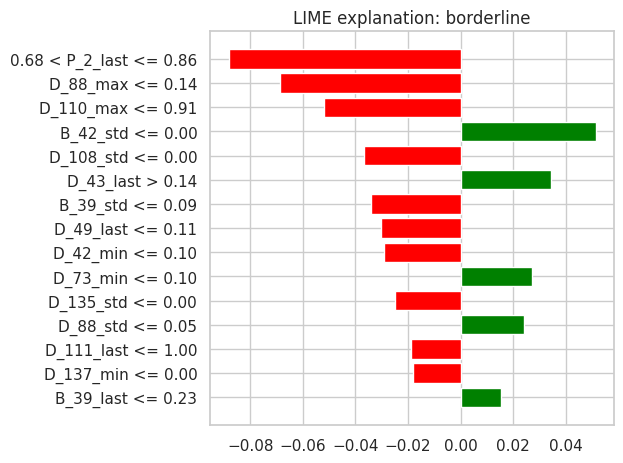

In [29]:
diagnostics = pd.DataFrame({
    "customer_ID": train_ids,
    "target": target,
    "oof_prediction": oof,
})

example_rows = {
    "high_risk": diagnostics["oof_prediction"].idxmax(),
    "low_risk": diagnostics["oof_prediction"].idxmin(),
    "borderline": (diagnostics["oof_prediction"] - diagnostics["oof_prediction"].median()).abs().idxmin(),
}

for name, row_idx in example_rows.items():
    print("=" * 80)
    print(name, diagnostics.loc[row_idx, ["customer_ID", "target", "oof_prediction"]].to_dict())
    exp = lime_explainer.explain_instance(
        X.loc[[row_idx]].fillna(numeric_medians).iloc[0].to_numpy(dtype=np.float32),
        lime_predict_fn,
        num_features=15,
        labels=[1],
    )
    display(pd.DataFrame(exp.as_list(label=1), columns=["feature_condition", "local_weight"]))
    fig = exp.as_pyplot_figure(label=1)
    plt.title(f"LIME explanation: {name}")
    plt.tight_layout()
    plt.show()

#### **Further Improvements**

- Add more temporal features: recent 3-month aggregates, slopes, missingness deltas, and lagged changes.
- Tune with more Optuna trials after the pipeline is stable.
- Ensemble multiple seeds or blend LightGBM with CatBoost/XGBoost.
- Validate interpretability conclusions across folds, not only `models[0]`.